In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [2]:
data = pd.read_csv("/content/adult.data")
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
data.columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'educational-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]

In [4]:
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32560 non-null  int64 
 1   workclass        32560 non-null  object
 2   fnlwgt           32560 non-null  int64 
 3   education        32560 non-null  object
 4   educational-num  32560 non-null  int64 
 5   marital-status   32560 non-null  object
 6   occupation       32560 non-null  object
 7   relationship     32560 non-null  object
 8   race             32560 non-null  object
 9   gender           32560 non-null  object
 10  capital-gain     32560 non-null  int64 
 11  capital-loss     32560 non-null  int64 
 12  hours-per-week   32560 non-null  int64 
 13  native-country   32560 non-null  object
 14  income           32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
data.shape

(32560, 15)

In [8]:
data.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [10]:
X = data[["age", "hours-per-week"]]

print("Features selected for clustering: Age and Hours per Week")

Features selected for clustering: Age and Hours per Week


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling complete using StandardScaler")

Feature scaling complete using StandardScaler


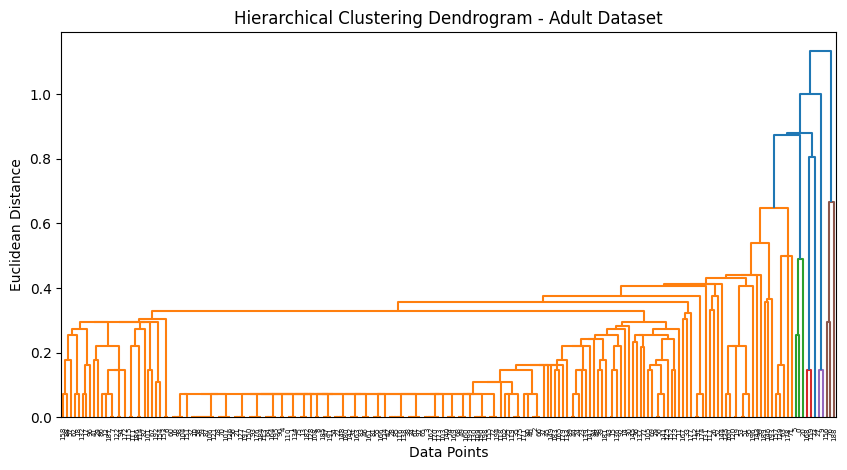

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_scaled[:200], method="single")

plt.figure(figsize=(10, 5))

dendrogram(
    linked,
    orientation="top",
    distance_sort="descending",
    show_leaf_counts=True
)

plt.title("Hierarchical Clustering Dendrogram - Adult Dataset")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()